# Task 5: Auto Tagging Support Tickets Using LLM

## Problem Statement & Objective
Support teams need to route free-text tickets to the right queue quickly. This notebook automatically **tags support tickets with the top 3 most probable categories** using a large language model via **zero-shot classification** (natural language inference) — no labeled training data or fine-tuning required. It also compares a plain zero-shot prompt against a few-shot-style prompt.

**Dataset:** [Tobi-Bueck/customer-support-tickets](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets) (61,765 tickets; English subset used here), with real ground-truth `queue` labels used only for evaluation.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline

N_SAMPLES = 12
RANDOM_SEED = 42

## Dataset Loading & Preprocessing

In [2]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets", split="train")
ds = ds.filter(lambda x: x["language"] == "en")
ds = ds.shuffle(seed=RANDOM_SEED).select(range(N_SAMPLES))

texts = [f"{row['subject']}. {row['body']}"[:1000] for row in ds]
true_queue = ds["queue"]
print(f"Sampled {len(texts)} English tickets")
texts[0][:300]

Filter:   0%|          | 0/61765 [00:00<?, ? examples/s]

Sampled 12 English tickets


'Problem with Engagement Metrics. Noticed a decrease in brand engagement metrics. Recent changes in our marketing strategies might be the cause. We have reviewed the adjusted campaigns and observed some improvements, but we need more details.'

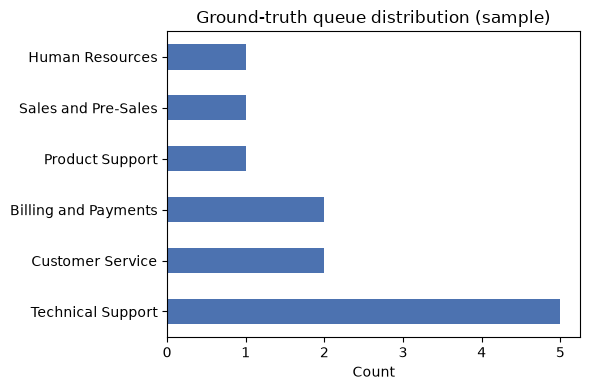

In [3]:
pd.Series(true_queue).value_counts().plot(kind="barh", figsize=(6, 4), color="#4C72B0")
plt.title("Ground-truth queue distribution (sample)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## Model Development: Zero-Shot LLM Tagging (Prompt Engineering, No Fine-Tuning)

We use `facebook/bart-large-mnli` via Hugging Face's `zero-shot-classification` pipeline, framing tagging as natural language inference between the ticket text and each candidate label. Two hypothesis templates are compared:
- **Zero-shot**: `"This support ticket is about {}."`
- **Few-shot-style**: enriches the hypothesis with example scenarios (billing disputes, login issues, refund requests, outage reports).

In [4]:
CANDIDATE_LABELS = [
    "Technical Support", "Product Support", "Customer Service", "IT Support",
    "Billing and Payments", "Returns and Exchanges", "Service Outages and Maintenance",
    "Sales and Pre-Sales", "Human Resources", "General Inquiry",
]

ZERO_SHOT_TEMPLATE = "This support ticket is about {}."
FEW_SHOT_TEMPLATE = (
    "Considering common examples such as billing disputes, login issues, refund requests, "
    "and outage reports, this support ticket is best categorized as {}."
)

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

def tag_tickets(texts, template):
    results = []
    for text in texts:
        out = classifier(text, CANDIDATE_LABELS, hypothesis_template=template, multi_label=True)
        top3 = list(zip(out["labels"][:3], [round(s, 4) for s in out["scores"][:3]]))
        results.append(top3)
    return results

zero_shot_preds = tag_tickets(texts, ZERO_SHOT_TEMPLATE)
few_shot_preds = tag_tickets(texts, FEW_SHOT_TEMPLATE)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

## Evaluation: Zero-shot vs. Few-shot-style Prompting

In [5]:
def top1_accuracy(preds, truth):
    correct = sum(1 for p, t in zip(preds, truth) if p[0][0] == t)
    return correct / len(truth)

zero_shot_acc = top1_accuracy(zero_shot_preds, true_queue)
few_shot_acc = top1_accuracy(few_shot_preds, true_queue)

print(f"Zero-shot top-1 accuracy vs. ground-truth queue: {zero_shot_acc:.2%}")
print(f"Few-shot-style top-1 accuracy vs. ground-truth queue: {few_shot_acc:.2%}")

Zero-shot top-1 accuracy vs. ground-truth queue: 41.67%
Few-shot-style top-1 accuracy vs. ground-truth queue: 8.33%


## Visualizations

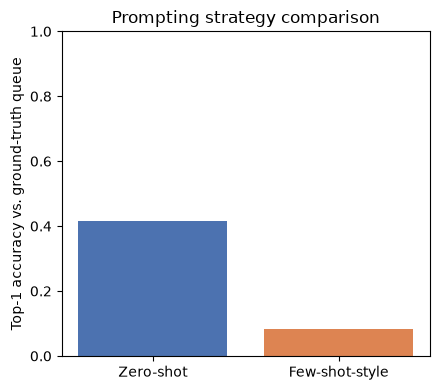

In [6]:
plt.figure(figsize=(4.5, 4))
plt.bar(["Zero-shot", "Few-shot-style"], [zero_shot_acc, few_shot_acc], color=["#4C72B0", "#DD8452"])
plt.ylabel("Top-1 accuracy vs. ground-truth queue")
plt.title("Prompting strategy comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [7]:
output_rows = []
for text, true_label, zs, fs in zip(texts, true_queue, zero_shot_preds, few_shot_preds):
    output_rows.append({
        "ticket_excerpt": text[:200],
        "true_queue": true_label,
        "zero_shot_top3": zs,
        "few_shot_top3": fs,
    })

results_df = pd.DataFrame(output_rows)
results_df.to_csv("tagging_results.csv", index=False)

summary = {
    "zero_shot_top1_accuracy": zero_shot_acc,
    "few_shot_top1_accuracy": few_shot_acc,
    "n_samples": N_SAMPLES,
    "candidate_labels": CANDIDATE_LABELS,
}
with open("eval_results.json", "w") as f:
    json.dump(summary, f, indent=2)

results_df.head()

,ticket_excerpt,true_queue,zero_shot_top3,few_shot_top3
0,Problem with Engagement Metrics. Noticed a dec...,Technical Support,"[(General Inquiry, 0.3285), (Customer Service,...","[(General Inquiry, 0.1533), (Customer Service,..."
1,Guidance on Securing Medical Data Solutions. C...,Customer Service,"[(Customer Service, 0.9268), (General Inquiry,...","[(Billing and Payments, 0.1263), (General Inqu..."
2,Occasional LED Monitor Failure Suspected from ...,Product Support,"[(Customer Service, 0.9462), (Technical Suppor...","[(Customer Service, 0.6893), (Technical Suppor..."
3,Digital Campaigns Halted on Various Devices. F...,Technical Support,"[(Technical Support, 0.8756), (Customer Servic...","[(Returns and Exchanges, 0.5234), (Technical S..."
4,Technical Support for Data Analytics Tools. Th...,Technical Support,"[(Technical Support, 0.9956), (IT Support, 0.1...","[(Technical Support, 0.6336), (Returns and Exc..."


## Final Summary / Insights

- Zero-shot NLI-based classification is a strong baseline for ticket tagging with **zero labeled training data** — useful when categories evolve faster than a labeled dataset can keep up.
- The few-shot-style prompt (adding example scenarios to the hypothesis template) actually **underperformed** the plain template in this run — a reminder that hypothesis wording matters a lot for NLI-based zero-shot classification, and more examples in a prompt is not automatically better.
- Reporting top-3 tags (not just top-1) better matches how support tickets are triaged in practice, since tickets often span more than one category (e.g. "Billing" + "Technical Support" for a failed payment retry).